In [76]:
import pandas as pd
import re
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent.resolve()))
from src.paths import *
import numpy as np

In [77]:
df = pd.read_excel(VALIDATION_SAMPLE)

## Technologies

In [78]:
def find_language_robust(tags_text, target_languages):
    """
    Check if any target language is present in the tags string using a robust
    regex that handles special characters like '+' and '#'.

    Returns the matched language (original capitalization) or 'n/a' if none found.
    """
    if pd.isna(tags_text) or not tags_text.strip():
        return 'n/a'

    tags_text_lower = tags_text.lower()

    for lang in target_languages:
        lang_lower = lang.lower()
        lang_escaped = re.escape(lang_lower)

        regex_search = r'(^|,\s*)' + lang_escaped + r'(\s*,|$)'

        if re.search(regex_search, tags_text_lower):
            return lang

    return 'n/a'


LANGUAGES = ['Python', 'JavaScript', 'Java', 'PHP', 'C++', 'C#', 'C', 'Obj-C', 'Go',
              'Perl', 'Ruby', 'Delphi', 'Powershell', 'SQL', 'TSQL', 'Vbnet', 'Lisp', 'Lua', 'Bash',
              'R', 'Haskell', 'Matlab', 'Rust']
LOWERCASE_LANGUAGES = [lang.lower() for lang in LANGUAGES]

# Apply language detection
df['language'] = df['technologies'].str.lower().apply(lambda x: find_language_robust(x, LANGUAGES))

In [79]:
language_percentages = df['language'].value_counts() / df.shape[0] * 100
language_percentages

language
n/a           58.028169
Java           9.014085
PHP            7.605634
Python         7.605634
C#             6.197183
C++            3.661972
Bash           1.408451
C              1.408451
Rust           0.845070
JavaScript     0.845070
Ruby           0.845070
Go             0.563380
SQL            0.563380
Lua            0.281690
Matlab         0.281690
Haskell        0.281690
R              0.281690
Powershell     0.281690
Name: count, dtype: float64

In [80]:
language_percentages = language_percentages.drop('n/a', errors='ignore')

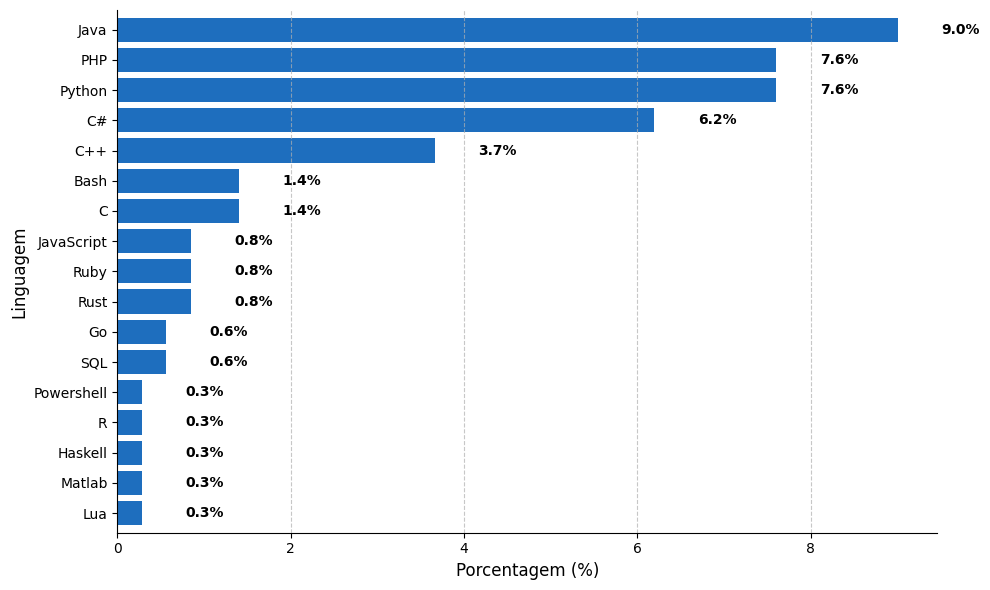

In [81]:
import matplotlib.pyplot as plt

language_percentages = language_percentages.sort_values(ascending=True)

plt.figure(figsize=(10, 6))

ax = language_percentages.plot.barh(color="#1e6ebe", width=0.8)

#plt.title('Distribuição de Linguagens de Programação', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Porcentagem (%)', fontsize=12)
plt.ylabel('Linguagem', fontsize=12)

for i, v in enumerate(language_percentages):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.spines['top'].set_visible(False)   
ax.spines['right'].set_visible(False) 
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

In [82]:
def remove_languages_from_technologies(tech_string, languages_to_remove):
    """
    Remove the specified languages from the technologies string.
    Returns 'n/a' if the resulting list is empty or input is missing.
    """
    if pd.isna(tech_string) or not tech_string.strip():
        return 'n/a'
    
    tech_list = [tech.strip() for tech in tech_string.split(',')]
    filtered_list = [tech for tech in tech_list if tech.lower() not in [lang.lower() for lang in languages_to_remove]]
    
    return ', '.join(filtered_list) if filtered_list else 'n/a'


# Apply language removal to create a cleaned technologies column
df['technologies_clean'] = df['technologies'].apply(lambda x: remove_languages_from_technologies(x, LANGUAGES))

In [83]:
def normalize_technology_terms(cell: str) -> str:
    """Normalize technology terms to canonical short forms."""
    if not isinstance(cell, str):
        return cell

    normalization_map = {
        "aes-128": "aes",
        "aes-256": "aes",
        "rijndael": "aes",
        "aes-ni": "aes",

        "pkcs1": "pkcs",
        "pkcs#1": "pkcs",
        "pkcs5": "pkcs",
        "pkcs#5": "pkcs",
        "pkcs7": "pkcs",
        "pkcs#7": "pkcs",
        "pkcs11": "pkcs",
        "pkcs11.net": "pkcs",
        "pkcs11interop": "pkcs",
        "pkcs12": "pkcs",
        "pkcs#12": "pkcs",

        "sha1": "sha1",
        "sha-1": "sha1",
        "sha256": "sha",
        "sha-256": "sha",
        "sha512": "sha",
        "sha-512": "sha",
        "sha2": "sha",
    }

    normalized_terms = []

    for term in cell.split(","):
        t = term.strip().lower()
        t = re.sub(r"\s+", " ", t)
        normalized_terms.append(normalization_map.get(t, t))

    return ", ".join(normalized_terms)


# Apply normalization to cleaned technologies
df['technologies_clean'] = df['technologies_clean'].apply(normalize_technology_terms)

In [84]:
exploded = (
    df['technologies_clean']
        .str.split(',')
        .explode()
        .str.strip()
        .str.replace('\xa0', '', regex=False)
        .str.lower()
        .replace('', pd.NA)
        .dropna()
)
clean_word_counts = exploded.value_counts()

In [85]:
len(exploded.unique())  # Total unique techs

194

In [86]:
pd.set_option('display.max_rows', None)
clean_word_counts / df.shape[0] * 100

technologies_clean
openssl                      20.281690
aes                          16.056338
sha                          13.521127
md5                          10.704225
rsa                          10.140845
n/a                           8.450704
ssl                           8.169014
pkcs                          5.915493
.net                          5.352113
hash                          4.225352
base64                        4.225352
sha1                          3.943662
iv                            3.943662
xor                           3.380282
tls                           3.380282
cbc                           3.098592
bcrypt                        2.816901
pgp                           2.535211
mysql                         1.690141
ssh                           1.408451
ecb                           1.408451
pbkdf                         1.408451
bouncycastle                  1.408451
ctr                           1.408451
mac                           1.126761
gcm   

## Tecnologies along topics

In [93]:
# Same numbers as the table of RQ1 in article
topic_names = {
    "01": "OpenSSL installation/build and runtime errors",
    "02": "Encoding and byte/string conversions (Base64, binary)",
    "03": "X.509 certificates, signing, and trust chains",
    "04": "Password hashing with salt (bcrypt, rainbow tables)",
    "05": "Crypto library/API implementation in code",
    "06": "Number theory for crypto (primes, factoring, modular arithmetic)",
    "07": "Public-key cryptography: encryption and digital signatures",
    "08": "Block cipher modes, IV/nonce, and padding",
    "09": "Client-server secure communication (HTTP/HTTPS, sessions)",
    "10": "User authentication and account management",
    "11": "File handling, integrity checks & checksums",
    "12": "Security vs performance (cost, speed, hardware limits)",
    "13": "Password strength and entropy estimation",
    "14": "Secure random number generation (entropy, seeding, PRNG)",
    "15": "Cryptographic hash functions & collisions",
    "16": "Key sizes and security parameters selection",
    "17": "Key protection on devices (memory/disk access, threat model)",
    "18": "Application data encryption & key storage",
    "19": "Cryptosystem design pitfalls & attack resistance",
    "20": "Trust, vendors, and real-world security risk",
    "21": "Conceptual crypto explanations and learning",
}

tmp_df = df[['topic', 'technologies_clean']].copy()
tmp_df['post_id'] = tmp_df.index
tmp_df = tmp_df.assign(tech=tmp_df['technologies_clean'].str.split(',')).explode('tech')

tmp_df['tech'] = tmp_df['tech'].astype(str).str.strip().str.lower()
tmp_df['tech'] = tmp_df['tech'].replace({'': 'n/a', 'nan': 'n/a', 'none': 'n/a'}).fillna('n/a')

posts_per_topic = df.groupby('topic').size().to_dict()
tech_topic_counts = tmp_df.groupby(['tech', 'topic'])['post_id'].nunique().reset_index()
tech_topic_counts.columns = ['tech', 'topic', 'count']

tech_topic_counts['pct'] = tech_topic_counts.apply(
    lambda row: (row['count'] / posts_per_topic.get(row['topic'], 1)) * 100,
    axis=1
)

tech_topic_counts = tech_topic_counts.sort_values(by=['tech', 'pct'], ascending=[True, False])

name_to_id = {v: k for k, v in topic_names.items()}

def format_row(row):
    topic_name = str(row["topic"])
    topic_id = name_to_id.get(topic_name, "??????????????????")
    return f"T{topic_id} ({row['pct']:.2f}%)"

tech_topic_counts['topic_formatted'] = tech_topic_counts.apply(format_row, axis=1)

final_table = (
    tech_topic_counts
    .groupby('tech')['topic_formatted']
    .apply(lambda x: ", ".join(x))
    .reset_index()
)

print(f"{'TECHNOLOGY':<25} | {'ASSOCIATED TOPICS'}")
print("-" * 120)

for _, row in final_table.iterrows():
    tech_name = row['tech'].upper()
    if tech_name.strip() in ('', 'NAN', 'N/A'):
        tech_name = 'N/A'
    print(f"{tech_name:<25} | {row['topic_formatted']}")

TECHNOLOGY                | ASSOCIATED TOPICS
------------------------------------------------------------------------------------------------------------------------
.NET                      | T05 (17.39%), T16 (11.11%), T02 (10.81%), T14 (10.00%), T17 (9.09%), T18 (8.33%), T10 (8.33%), T04 (8.00%), T03 (7.41%), T11 (6.67%), T01 (1.82%)
.NET REFLECTOR            | T05 (4.35%)
AAD                       | T08 (4.76%)
AEAD                      | T08 (4.76%)
AES                       | T16 (66.67%), T08 (61.90%), T19 (57.14%), T18 (50.00%), T12 (45.45%), T06 (27.78%), T05 (26.09%), T14 (20.00%), T20 (14.29%), T07 (11.11%), T11 (6.67%), T02 (5.41%), T04 (4.00%)
AGCD                      | T06 (5.56%)
APK                       | T11 (6.67%)
ARC4                      | T05 (4.35%)
ARGON2                    | T12 (18.18%), T10 (8.33%)
AS3CRYPTO                 | T02 (2.70%)
ASP.NET                   | T08 (4.76%), T04 (4.00%), T02 (2.70%)
AWS                       | T01 (1.82%)
BACKDOORS    

## Technologies over time

In [89]:
df = pd.read_csv(CLASSIFIED_POSTS)
df = df[df['type'] == 'question']

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\dev\\social-media-dev-crawler\\data\\Lda\\csvs\\classified_posts.csv'

In [ ]:
import matplotlib.pyplot as plt

df['creation_date'] = pd.to_datetime(df['creation_date'], errors='coerce')
df['year'] = df['creation_date'].dt.year

topic_by_year = df.groupby(['year', 'topic']).size().reset_index(name='count')
total_by_year = df.groupby('year').size().reset_index(name='total')

topic_by_year = topic_by_year.merge(total_by_year, on='year')
topic_by_year['percentage'] = (topic_by_year['count'] / topic_by_year['total']) * 100

ordered_topic_keys = sorted(topic_names.keys()) 
n_topics = len(ordered_topic_keys)

fig, axes = plt.subplots(n_topics, 1, figsize=(10, 2.5 * n_topics), sharex=True)

if n_topics == 1:
    axes = [axes]

colors = plt.cm.tab20(range(20)) 

for idx, key in enumerate(ordered_topic_keys):
    ax = axes[idx]
    ax2 = ax.twinx()
    
    topic_name_in_df = topic_names[key]
    
    topic_data = topic_by_year[topic_by_year['topic'] == topic_name_in_df].sort_values('year')
    
    color = colors[idx % 20]
    
    if not topic_data.empty:
        ax.plot(topic_data['year'], topic_data['count'], 
                marker='o', linewidth=2, markersize=4, 
                color=color, label='Contagem', alpha=0.8)
        
        ax2.plot(topic_data['year'], topic_data['percentage'], 
                 marker='s', linewidth=2, markersize=3,
                 color=color, label='Porcentagem', linestyle='--', alpha=0.6)
    
    ax.set_ylabel('Contagem', fontsize=8, fontweight='bold')
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(True, alpha=0.2, linestyle='--')
    
    ax2.set_ylabel('Porcentagem', fontsize=8, fontweight='bold', rotation=270, labelpad=15)
    ax2.tick_params(axis='y', labelsize=7)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}%'))
    
    ax.set_title(f'T{key}: {topic_name_in_df}', fontsize=10, fontweight='bold', loc='left', pad=5)
    
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, ['Contagem (esq.)', 'Porcentagem (dir.)'], 
              loc='upper right', fontsize=7, framealpha=0.8)

axes[-1].set_xlabel('Ano', fontsize=10, fontweight='bold')
axes[-1].tick_params(axis='x', labelsize=9)

plt.suptitle('Evolução dos Tópicos ao Longo do Tempo', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.show()